# Modelo Naive Bayes 

In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



In [4]:
ruta = r'C:\docs\DOCTORADO\Machine_Learning/tornados.csv'  
df = pd.read_csv(ruta) 

In [258]:
df_ml = df.copy()


In [259]:
# Crear una copia del DataFrame original para el preprocesamiento
df_ml = df.copy()

# Eliminar columnas que no aportan valor predictivo o son redundantes
df_ml.drop(['om', 'date', 'time', 'datetime_utc', 'stf', 'fat', 'f1', 'f2', 'f3', 'f4'], axis=1, inplace=True)

# Eliminar filas con valores nulos
df_ml.dropna(inplace=True)

# Asegurar que 'fc' esté en formato numérico
df_ml['fc'] = df_ml['fc'].astype(int)

# Convertir variables categóricas en variables dummy, eliminando la primera columna de cada una
cat_columns = ['st', 'tz']
df_ml = pd.get_dummies(df_ml, columns=cat_columns, drop_first=True)

# Reemplazar valores booleanos por 0 y 1 si quedan
df_ml.replace({False: 0, True: 1}, inplace=True)

# Verificación final
print("Forma final del DataFrame para ML:", df_ml.shape)
print("Primeras filas del DataFrame preprocesado:")
df_ml.head()



Forma final del DataFrame para ML: (41517, 71)
Primeras filas del DataFrame preprocesado:


,yr,mo,dy,mag,inj,loss,slat,slon,elat,elon,...,st_TX,st_UT,st_VA,st_VT,st_WA,st_WI,st_WV,st_WY,tz_America/Denver,tz_UTC
0,1950,10,1,1.0,0,50000.0,36.73,-102.52,36.88,-102.3,...,0,0,0,0,0,0,0,0,0,0
1,1950,10,9,3.0,3,500000.0,34.17,-78.60,0.00,0.0,...,0,0,0,0,0,0,0,0,0,0
2,1950,11,20,2.0,0,500000.0,37.37,-87.20,0.00,0.0,...,0,0,0,0,0,0,0,0,0,0
3,1950,11,20,1.0,0,500000.0,38.20,-84.50,0.00,0.0,...,0,0,0,0,0,0,0,0,0,0
4,1950,11,20,1.0,3,50000.0,32.42,-89.13,0.00,0.0,...,0,0,0,0,0,0,0,0,0,0


In [260]:
# Separar variables predictoras (X) y variable objetivo (y)
X = df_ml.drop('mortality', axis=1)
y = df_ml['mortality']

In [261]:
from sklearn.model_selection import train_test_split

# Dividir los datos: 70% entrenamiento, 30% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=101, stratify=y  # estratifica para mantener proporciones de clase
)


In [262]:
from sklearn.preprocessing import StandardScaler

# Escalar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [263]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score
)
import pandas as pd
import time

# ⏱️ Medir tiempo de entrenamiento
start_time = time.time()

# 1. Instanciar y entrenar el modelo
clf = BernoulliNB()
clf.fit(X_train_scaled, y_train)

end_time = time.time()
tiempo_entrenamiento = end_time - start_time

# 2. Predecir en los datos de prueba
y_pred = clf.predict(X_test_scaled)
y_prob = clf.predict_proba(X_test_scaled)[:, 1]  # Necesario para AUC

# 3. Evaluar el desempeño
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

# 4. Guardar métricas en un DataFrame para comparación posterior
resultados_bayes = pd.DataFrame({
    'Modelo': ['Naive Bayes'],
    'Accuracy': [round(accuracy_score(y_test, y_pred), 4)],
    'Precision': [round(precision_score(y_test, y_pred), 4)],
    'Recall': [round(recall_score(y_test, y_pred), 4)],
    'F1-score': [round(f1_score(y_test, y_pred), 4)],
    'AUC': [round(roc_auc_score(y_test, y_prob), 4)],
    'CPU time (s)': [round(tiempo_entrenamiento, 4)]
})

# 5. Ver tabla con métricas
display(resultados_bayes)



Accuracy: 0.9362556197816313

Matriz de confusión:
 [[11365   661]
 [  133   297]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.99      0.95      0.97     12026
           1       0.31      0.69      0.43       430

    accuracy                           0.94     12456
   macro avg       0.65      0.82      0.70     12456
weighted avg       0.97      0.94      0.95     12456



,Modelo,Accuracy,Precision,Recall,F1-score,AUC,CPU time (s)
0,Naive Bayes,0.9363,0.31,0.6907,0.428,0.9092,0.0267


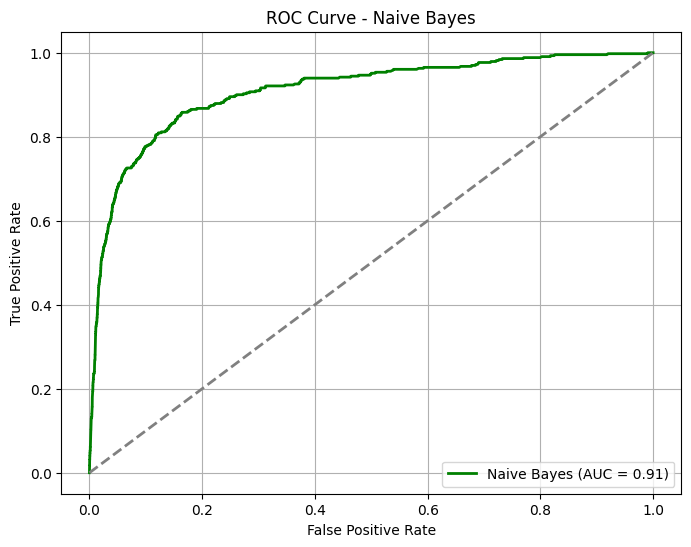

In [264]:

# ROC para Bayes
from sklearn.metrics import roc_curve, auc
y_prob_bayes = clf.predict_proba(X_test_scaled)[:, 1]
fpr_bayes, tpr_bayes, _ = roc_curve(y_test, y_prob_bayes)
roc_auc_bayes = auc(fpr_bayes, tpr_bayes)

plt.figure(figsize=(8,6))
plt.plot(fpr_bayes, tpr_bayes, color='green', lw=2, label='Naive Bayes (AUC = %0.2f)' % roc_auc_bayes)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naive Bayes')
plt.legend(loc="lower right")
plt.grid()
plt.show()

In [265]:
# Verificar desbalance en la variable objetivo 'mortality'
print("Distribución original de la variable 'mortality':")
print(y.value_counts())
print("\nProporciones:")
print(y.value_counts(normalize=True).rename("proportion"))


Distribución original de la variable 'mortality':
mortality
0    40083
1     1434
Name: count, dtype: int64

Proporciones:
mortality
0    0.96546
1    0.03454
Name: proportion, dtype: float64


## Naive Bayes balanceado con SMOTE

In [266]:
import time
import pandas as pd
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# 1. Repetimos la separación si no está hecha
X = df_ml.drop('mortality', axis=1)
y = df_ml['mortality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=101, stratify=y
)

# 2. Aplicar SMOTE solo al conjunto de entrenamiento
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Distribución después de SMOTE:")
print(y_train_sm.value_counts(normalize=True))

# 3. Escalar los datos
scaler = StandardScaler()
X_train_sm_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# 4. Entrenar modelo con cronómetro ⏱️
start_time = time.time()
model = BernoulliNB()
model.fit(X_train_sm_scaled, y_train_sm)
tiempo_entrenamiento = time.time() - start_time

# 5. Predecir sobre el conjunto de prueba (sin SMOTE)
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# 6. Evaluar resultados
print("\n🔍 Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\n📋 Reporte de clasificación:\n", classification_report(y_test, y_pred))

# 7. Guardar métricas en DataFrame
resultados_bayes_smote = pd.DataFrame({
    'Modelo': ['Naive Bayes (con SMOTE)'],
    'Accuracy': [round(accuracy_score(y_test, y_pred), 4)],
    'Precision': [round(precision_score(y_test, y_pred), 4)],
    'Recall': [round(recall_score(y_test, y_pred), 4)],
    'F1-score': [round(f1_score(y_test, y_pred), 4)],
    'AUC': [round(roc_auc_score(y_test, y_prob), 4)],
    'CPU time (s)': [round(tiempo_entrenamiento, 4)]
})

# 8. Mostrar resultados
display(resultados_bayes_smote)


Distribución después de SMOTE:
mortality
0    0.5
1    0.5
Name: proportion, dtype: float64

🔍 Accuracy: 0.9094412331406551

📊 Matriz de confusión:
 [[11044   982]
 [  146   284]]

📋 Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.99      0.92      0.95     12026
           1       0.22      0.66      0.33       430

    accuracy                           0.91     12456
   macro avg       0.61      0.79      0.64     12456
weighted avg       0.96      0.91      0.93     12456



,Modelo,Accuracy,Precision,Recall,F1-score,AUC,CPU time (s)
0,Naive Bayes (con SMOTE),0.9094,0.2243,0.6605,0.3349,0.8918,0.0426


## Aplicación de algoritmos de optimización 


### Partial_fit() para entrenamiento por lotes.

In [267]:
import time
import numpy as np
import pandas as pd
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

# Reinstanciar el modelo
nb_partial = BernoulliNB()

# Medir el tiempo de entrenamiento
start_time = time.time()
nb_partial.partial_fit(X_train_scaled, y_train, classes=np.unique(y))
tiempo_entrenamiento = time.time() - start_time

# Predecir
y_pred_partial = nb_partial.predict(X_test_scaled)
y_prob_partial = nb_partial.predict_proba(X_test_scaled)[:, 1]

# Evaluar
print("🔧 Accuracy (con partial_fit):", accuracy_score(y_test, y_pred_partial))
print("\n📊 Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_partial))
print("\n📋 Reporte de Clasificación:\n", classification_report(y_test, y_pred_partial))

# Guardar resultados en DataFrame
resultados_bayes_partial = pd.DataFrame({
    'Modelo': ['Naive Bayes (partial_fit)'],
    'Accuracy': [round(accuracy_score(y_test, y_pred_partial), 4)],
    'Precision': [round(precision_score(y_test, y_pred_partial), 4)],
    'Recall': [round(recall_score(y_test, y_pred_partial), 4)],
    'F1-score': [round(f1_score(y_test, y_pred_partial), 4)],
    'AUC': [round(roc_auc_score(y_test, y_prob_partial), 4)],
    'CPU time (s)': [round(tiempo_entrenamiento, 4)]
})

# Mostrar
display(resultados_bayes_partial)



🔧 Accuracy (con partial_fit): 0.9678869621066153

📊 Matriz de Confusión:
 [[11890   136]
 [  264   166]]

📋 Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98     12026
           1       0.55      0.39      0.45       430

    accuracy                           0.97     12456
   macro avg       0.76      0.69      0.72     12456
weighted avg       0.96      0.97      0.97     12456



,Modelo,Accuracy,Precision,Recall,F1-score,AUC,CPU time (s)
0,Naive Bayes (partial_fit),0.9679,0.5497,0.386,0.4536,0.8887,0.022


## Aplicación de Pipeline y Gridsearch

In [1]:
# 📦 LIBRERÍAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import glob
from joblib import dump, load
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

# 📂 CARGA DE DATOS
ruta = r'C:\docs\DOCTORADO\Machine_Learning\tornados.csv'
df = pd.read_csv(ruta)
df['mortality'] = np.where(df['fat'] == 0, 0, 1)

In [2]:
# 🧹 PREPROCESAMIENTO
df_ml = df.copy()
df_ml.drop(['om', 'date', 'time', 'datetime_utc', 'stf', 'fat', 'f1', 'f2', 'f3', 'f4'], axis=1, inplace=True)
df_ml.dropna(inplace=True)
df_ml['fc'] = df_ml['fc'].astype(int)
df_ml = pd.get_dummies(df_ml, columns=['st', 'tz'], drop_first=True)
df_ml.replace({False: 0, True: 1}, inplace=True)

C:\Users\Yuliceth Ramos\AppData\Local\Temp\ipykernel_29448\1702169410.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_ml.replace({False: 0, True: 1}, inplace=True)


In [3]:
# 📊 SEPARACIÓN
X = df_ml.drop('mortality', axis=1)
y = df_ml['mortality']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

In [ ]:
param_grid = {
    'nb__alpha': [0.1, 0.5, 1.0, 2.0],  # Suavizado
    'nb__binarize': [0.0, 0.5, 1.0]     # Umbral de binarización
}

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('nb', BernoulliNB())
])

grid = None
if len(glob.glob("grid_bayes.joblib")) != 0:
    grid = load("grid_bayes.joblib")
else:
    time_start = time.process_time()
    grid = GridSearchCV(pipe, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train, y_train)
    time_stop = time.process_time()

    print("Tiempo total (CPU):", round((time_stop - time_start), 2), "s")
    dump(grid, "grid_bayes.joblib")

Tiempo total (CPU): 0.61 s


In [ ]:
# 🔍 EVALUACIÓN
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]

resultados_bayes_pip_grid = pd.DataFrame({
    'Modelo': ['Naive Bayes + GridSearch'],
    'Accuracy': [round(accuracy_score(y_test, y_pred), 4)],
    'Precision': [round(precision_score(y_test, y_pred), 4)],
    'Recall': [round(recall_score(y_test, y_pred), 4)],
    'F1-score': [round(f1_score(y_test, y_pred), 4)],
    'AUC': [round(roc_auc_score(y_test, y_prob), 4)],
    'CPU time (s)': [round((time_stop - time_start), 2)]
})

display(resultados_bayes_pip_grid)

,Modelo,Accuracy,Precision,Recall,F1-score,AUC,CPU time (s)
0,Naive Bayes + GridSearch,0.941,0.3277,0.6744,0.4411,0.9067,0.61


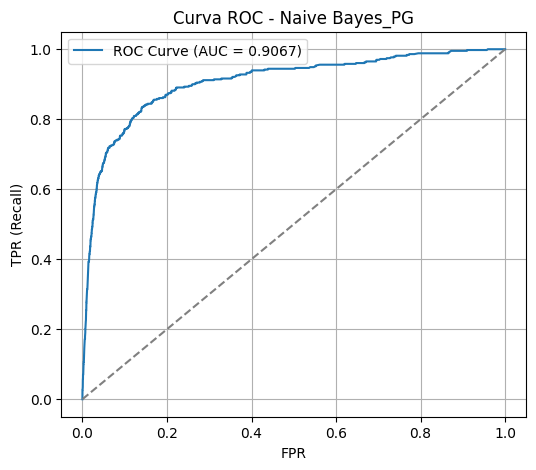

In [10]:
# 📈 CURVA ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='ROC Curve (AUC = {:.4f})'.format(roc_auc_score(y_test, y_prob)))
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('FPR')
plt.ylabel('TPR (Recall)')
plt.title('Curva ROC - Naive Bayes_PG')
plt.legend()
plt.grid(True)
plt.show()

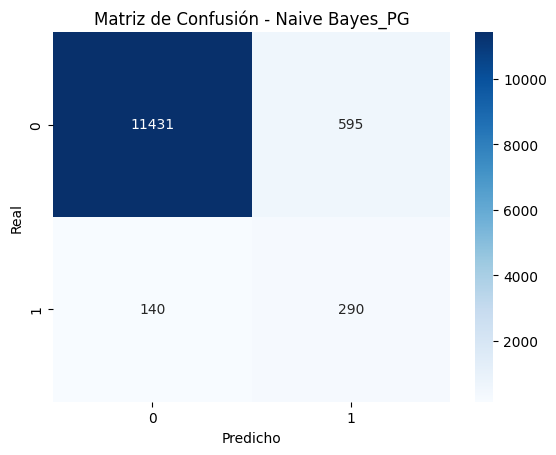

In [11]:
# 🔲 MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
plt.title('Matriz de Confusión - Naive Bayes_PG')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()